In [2]:
# ============================================================
# CT-CLIP Grad-CAM Visualization Notebook
# ============================================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

import torch


# ============================================================
# Imports
# ============================================================

sys.path.insert(
    0,
    "/home/chest_ct/code/models/ct-clip/scripts"
)


from rexground_pilot_pipeline import (
    preprocess_ct,
    TRAIN_META,
    VALID_META,
    SEG_DIR,
    ROOT,
    TARGET_SHAPE,
    TARGET_SPACING,
    VOLUME_DIR
)

from data import resize_array



# ============================================================
# Select best CT-CLIP Grad-CAM case
# ============================================================

name = "train_655_a_2.nii.gz"

summary_path = (
    ROOT /
    "rexground_predictions/full/gradcam_summary_top20.csv"
)


summary = pd.read_csv(summary_path)


row = summary[
    summary["name"] == name
].iloc[0]


print(row)



# ============================================================
# Load metadata
# ============================================================

train_meta = pd.read_csv(
    TRAIN_META
).set_index("VolumeName")


valid_meta = pd.read_csv(
    VALID_META
).set_index("VolumeName")


if name in train_meta.index:
    meta_row = train_meta.loc[name]
else:
    meta_row = valid_meta.loc[name]


print("\nMetadata loaded")



# ============================================================
# Load CT using CT-CLIP preprocessing
# ============================================================

image_tensor, crop_info = preprocess_ct(
    VOLUME_DIR / name,
    meta_row
)


# CT-CLIP format:
# Z,X,Y

img_zxy = image_tensor.squeeze().numpy()


# Convert:
# X,Y,Z

img_xyz = np.transpose(
    img_zxy,
    (1,2,0)
)


print("\nCT shape:")
print(img_xyz.shape)



# ============================================================
# Ground truth alignment
# ============================================================

def aligned_gt_mask(name, crop_info, meta_row):

    seg_nii = nib.load(
        str(SEG_DIR / name)
    )

    seg = seg_nii.get_fdata()


    if seg.ndim == 4:
        seg = seg[0]


    seg_mask = seg > 0


    # XYZ -> ZXY
    seg_zxy = np.transpose(
        seg_mask.astype(np.float32),
        (2,0,1)
    )


    seg_tensor = torch.tensor(
        seg_zxy
    )[None,None]


    xy_spacing = float(
        meta_row["XYSpacing"][1:][:-2].split(",")[0]
    )


    z_spacing = float(
        meta_row["ZSpacing"]
    )


    # same resampling as CT pipeline

    seg_resized = resize_array(
        seg_tensor,
        (
            z_spacing,
            xy_spacing,
            xy_spacing
        ),
        TARGET_SPACING
    )[0,0]


    # ZXY -> XYZ

    seg_resized = np.transpose(
        seg_resized.numpy(),
        (1,2,0)
    )


    dh, dw, dd = TARGET_SHAPE


    hs = crop_info["h_start"]
    ws = crop_info["w_start"]
    ds = crop_info["d_start"]


    seg_crop = seg_resized[
        hs:hs+dh,
        ws:ws+dw,
        ds:ds+dd
    ]


    seg_pad = np.pad(
        seg_crop,
        (
            (
                crop_info["pad_h_before"],
                dh - seg_crop.shape[0]
                - crop_info["pad_h_before"]
            ),
            (
                crop_info["pad_w_before"],
                dw - seg_crop.shape[1]
                - crop_info["pad_w_before"]
            ),
            (
                crop_info["pad_d_before"],
                dd - seg_crop.shape[2]
                - crop_info["pad_d_before"]
            )
        ),
        mode="constant",
        constant_values=0
    )


    return seg_pad > 0.5



gt_mask = aligned_gt_mask(
    name,
    crop_info,
    meta_row
)


print("\nGT shape:")
print(gt_mask.shape)


print(
    "GT voxels:",
    gt_mask.sum()
)



# ============================================================
# Load CT-CLIP Grad-CAM
# ============================================================

cam_path = row["gradcam_npy"]


cam_zxy = np.load(
    cam_path
)


# Z,X,Y -> X,Y,Z

cam_xyz = np.transpose(
    cam_zxy,
    (1,2,0)
)


print("\nCAM shape:")
print(cam_xyz.shape)


print(
    "CAM range:",
    cam_xyz.min(),
    cam_xyz.max()
)



# ============================================================
# Select slice with largest lesion area
# ============================================================

slice_idx = np.argmax(
    gt_mask.sum(axis=(0,1))
)


print(
    "\nVisualization slice:",
    slice_idx
)



# ============================================================
# Visualization
# ============================================================

plt.figure(
    figsize=(18,6)
)



# -------------------------
# CT
# -------------------------

plt.subplot(1,3,1)

plt.imshow(
    img_xyz[:,:,slice_idx],
    cmap="gray"
)

plt.title(
    f"{name}\nCT slice {slice_idx}"
)

plt.axis("off")



# -------------------------
# Ground Truth
# -------------------------

plt.subplot(1,3,2)

plt.imshow(
    img_xyz[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    np.ma.masked_where(
        gt_mask[:,:,slice_idx] == 0,
        gt_mask[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.6
)


plt.title(
    "Ground Truth"
)

plt.axis("off")



# -------------------------
# CT-CLIP Grad-CAM
# -------------------------

plt.subplot(1,3,3)

plt.imshow(
    img_xyz[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    cam_xyz[:,:,slice_idx],
    cmap="jet",
    alpha=0.5,
    vmin=0,
    vmax=1
)


plt.title(
    "CT-CLIP Grad-CAM"
)

plt.axis("off")



plt.tight_layout()

plt.show()

name                                                 train_655_a_2.nii.gz
split                                                                test
kind                                                                  ggo
categories                                                             2c
pixels                                                            1317095
findings                Bilateral multilobar, predominantly peripheral...
prob_lung_nodule                                                 0.495762
prob_lung_opacity                                                0.562429
logit_lung_nodule                                               -0.016953
logit_lung_opacity                                               0.251028
gradcam_target                                                        ggo
target_prob                                                      0.562429
gradcam_npy             /home/chest_ct/code/models/ct-clip/rexground_p...
gradcam_best_dice                     

AttributeError: 'numpy.ndarray' object has no attribute 'numpy'

In [3]:
# ============================================================
# CT-CLIP Grad-CAM Visualization Notebook (Corrected)
# ============================================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

import torch


# ============================================================
# Imports
# ============================================================

sys.path.insert(
    0,
    "/home/chest_ct/code/models/ct-clip/scripts"
)


from rexground_pilot_pipeline import (
    preprocess_ct,
    TRAIN_META,
    VALID_META,
    SEG_DIR,
    ROOT,
    TARGET_SHAPE,
    TARGET_SPACING,
    VOLUME_DIR
)

from data import resize_array



# ============================================================
# Select best CT-CLIP Grad-CAM case
# ============================================================

# Best case from your output:
# ggo train_655_a_2.nii.gz
# best_dice = 0.0139

name = "train_655_a_2.nii.gz"


summary_path = (
    ROOT /
    "rexground_predictions/full/gradcam_summary_top20.csv"
)


summary = pd.read_csv(summary_path)


row = summary[
    summary["name"] == name
].iloc[0]


print(row)



# ============================================================
# Load metadata
# ============================================================

train_meta = pd.read_csv(
    TRAIN_META
).set_index("VolumeName")


valid_meta = pd.read_csv(
    VALID_META
).set_index("VolumeName")


if name in train_meta.index:
    meta_row = train_meta.loc[name]
else:
    meta_row = valid_meta.loc[name]


print("\nMetadata loaded")



# ============================================================
# Load CT using CT-CLIP preprocessing
# ============================================================

image_tensor, crop_info = preprocess_ct(
    VOLUME_DIR / name,
    meta_row
)


# CT-CLIP output:
# Z,X,Y

img_zxy = image_tensor.squeeze().numpy()


# convert:
# X,Y,Z

img_xyz = np.transpose(
    img_zxy,
    (1,2,0)
)


print("\nCT shape:")
print(img_xyz.shape)



# ============================================================
# Load aligned GT mask
# ============================================================

def aligned_gt_mask(name, crop_info, meta_row):

    seg_nii = nib.load(
        str(SEG_DIR / name)
    )


    seg = seg_nii.get_fdata()


    if seg.ndim == 4:
        seg = seg[0]


    seg_mask = seg > 0



    # XYZ -> ZXY

    seg_zxy = np.transpose(
        seg_mask.astype(np.float32),
        (2,0,1)
    )


    seg_tensor = torch.tensor(
        seg_zxy
    )[None,None]



    xy_spacing = float(
        meta_row["XYSpacing"][1:][:-2].split(",")[0]
    )


    z_spacing = float(
        meta_row["ZSpacing"]
    )



    # Same resampling as CT pipeline

    seg_resized = resize_array(
        seg_tensor,
        (
            z_spacing,
            xy_spacing,
            xy_spacing
        ),
        TARGET_SPACING
    )[0,0]



    # ZXY -> XYZ

    seg_resized = np.transpose(
        seg_resized.numpy(),
        (1,2,0)
    )



    dh, dw, dd = TARGET_SHAPE


    hs = crop_info["h_start"]
    ws = crop_info["w_start"]
    ds = crop_info["d_start"]



    seg_crop = seg_resized[
        hs:hs+dh,
        ws:ws+dw,
        ds:ds+dd
    ]



    seg_pad = np.pad(
        seg_crop,
        (
            (
                crop_info["pad_h_before"],
                dh - seg_crop.shape[0]
                - crop_info["pad_h_before"]
            ),
            (
                crop_info["pad_w_before"],
                dw - seg_crop.shape[1]
                - crop_info["pad_w_before"]
            ),
            (
                crop_info["pad_d_before"],
                dd - seg_crop.shape[2]
                - crop_info["pad_d_before"]
            )
        ),
        mode="constant",
        constant_values=0
    )


    return seg_pad > 0.5




gt_mask = aligned_gt_mask(
    name,
    crop_info,
    meta_row
)



print("\nGT shape:")
print(gt_mask.shape)


print(
    "GT voxels:",
    gt_mask.sum()
)



# ============================================================
# Load CT-CLIP Grad-CAM
# ============================================================

cam_path = row["gradcam_npy"]


print(
    "\nLoading CAM:",
    cam_path
)


cam_zxy = np.load(
    cam_path
)



# CAM:
# Z,X,Y

cam_xyz = np.transpose(
    cam_zxy,
    (1,2,0)
)



print("\nCAM shape:")
print(cam_xyz.shape)


print(
    "CAM range before normalization:",
    cam_xyz.min(),
    cam_xyz.max()
)



# ============================================================
# Normalize CAM
# ============================================================

cam_xyz = cam_xyz - cam_xyz.min()


cam_xyz = cam_xyz / (
    cam_xyz.max() + 1e-8
)



print(
    "CAM range after normalization:",
    cam_xyz.min(),
    cam_xyz.max()
)



# ============================================================
# Check alignment
# ============================================================

print("\nShape check")

print(
    "CT:",
    img_xyz.shape
)

print(
    "GT:",
    gt_mask.shape
)

print(
    "CAM:",
    cam_xyz.shape
)



assert img_xyz.shape == gt_mask.shape == cam_xyz.shape, \
    "CT, GT and CAM shapes do not match"



# ============================================================
# Select best slice using CAM-GT overlap
# ============================================================

best_slice = -1
best_score = -1



for z in range(gt_mask.shape[2]):

    if gt_mask[:,:,z].sum() == 0:
        continue


    score = (
        cam_xyz[:,:,z] *
        gt_mask[:,:,z]
    ).sum()



    if score > best_score:

        best_score = score
        best_slice = z



slice_idx = best_slice



print(
    "\nSelected slice:",
    slice_idx
)


print(
    "CAM-GT overlap score:",
    best_score
)



# ============================================================
# Visualization
# ============================================================

plt.figure(
    figsize=(18,6)
)



# -------------------------
# CT
# -------------------------

plt.subplot(1,3,1)


plt.imshow(
    img_xyz[:,:,slice_idx],
    cmap="gray"
)


plt.title(
    f"{name}\nCT slice {slice_idx}"
)


plt.axis("off")



# -------------------------
# Ground Truth
# -------------------------

plt.subplot(1,3,2)


plt.imshow(
    img_xyz[:,:,slice_idx],
    cmap="gray"
)



plt.imshow(
    np.ma.masked_where(
        gt_mask[:,:,slice_idx] == 0,
        gt_mask[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.6
)



plt.title(
    "Ground Truth"
)


plt.axis("off")



# -------------------------
# CT-CLIP Grad-CAM
# -------------------------

plt.subplot(1,3,3)



plt.imshow(
    img_xyz[:,:,slice_idx],
    cmap="gray"
)



plt.imshow(
    cam_xyz[:,:,slice_idx],
    cmap="jet",
    alpha=0.5,
    vmin=0,
    vmax=1
)



# high activation boundary

plt.contour(
    cam_xyz[:,:,slice_idx],
    levels=[0.7],
    colors="yellow",
    linewidths=1
)



plt.title(
    "CT-CLIP Grad-CAM\n(yellow = high activation)"
)


plt.axis("off")



plt.tight_layout()

plt.show()

name                                                 train_655_a_2.nii.gz
split                                                                test
kind                                                                  ggo
categories                                                             2c
pixels                                                            1317095
findings                Bilateral multilobar, predominantly peripheral...
prob_lung_nodule                                                 0.495762
prob_lung_opacity                                                0.562429
logit_lung_nodule                                               -0.016953
logit_lung_opacity                                               0.251028
gradcam_target                                                        ggo
target_prob                                                      0.562429
gradcam_npy             /home/chest_ct/code/models/ct-clip/rexground_p...
gradcam_best_dice                     

AttributeError: 'numpy.ndarray' object has no attribute 'numpy'

name                                                 train_655_a_2.nii.gz
split                                                                test
kind                                                                  ggo
categories                                                             2c
pixels                                                            1317095
findings                Bilateral multilobar, predominantly peripheral...
prob_lung_nodule                                                 0.495762
prob_lung_opacity                                                0.562429
logit_lung_nodule                                               -0.016953
logit_lung_opacity                                               0.251028
gradcam_target                                                        ggo
target_prob                                                      0.562429
gradcam_npy             /home/chest_ct/code/models/ct-clip/rexground_p...
gradcam_best_dice                     

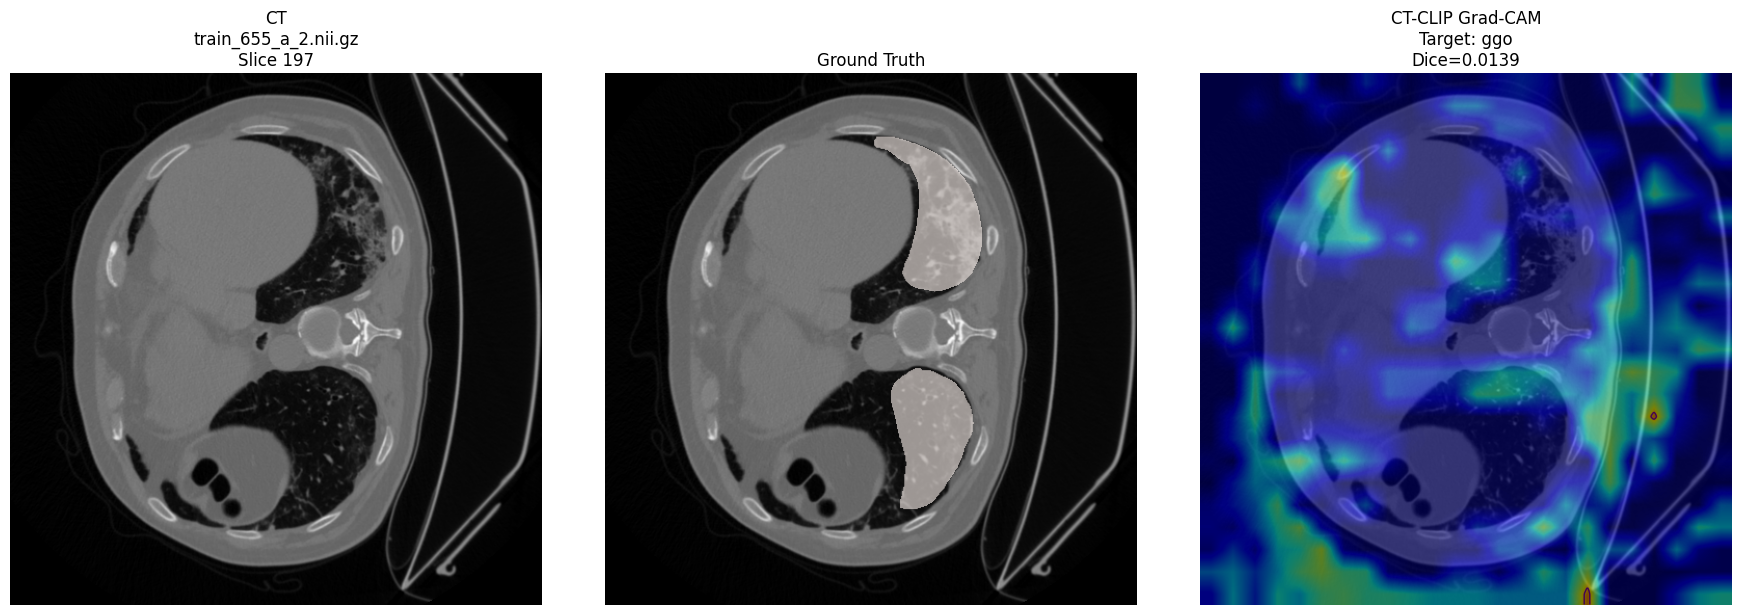


Saved visualization:
/home/chest_ct/code/models/ct-clip/rexground_predictions/full/visualizations/ggo_train_655_a_2.png


<Figure size 640x480 with 0 Axes>

In [4]:
# ============================================================
# CT-CLIP Grad-CAM Visualization Notebook
# Using original CT + GT paths (Merlin style)
# ============================================================


import os
import sys

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from scipy.ndimage import zoom



# ============================================================
# Paths
# ============================================================


CT_DIR = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed"

GT_DIR = "/home/chest_ct/code/data/segmentations/segmentations"


SUMMARY_PATH = (
    "/home/chest_ct/code/models/ct-clip/"
    "rexground_predictions/full/"
    "gradcam_summary_top20.csv"
)


# ============================================================
# Load Grad-CAM summary
# ============================================================


summary = pd.read_csv(
    SUMMARY_PATH
)


# select best Grad-CAM case
best_row = summary.loc[
    summary["gradcam_best_dice"].idxmax()
]


print(best_row)



name = best_row["name"]

cam_path = best_row["gradcam_npy"]

target = best_row["gradcam_target"]


print("\nSelected case:")
print(name)

print("Target:")
print(target)

print("CAM:")
print(cam_path)



# ============================================================
# Load CT and GT
# ============================================================


ct_path = os.path.join(
    CT_DIR,
    name
)


gt_path = os.path.join(
    GT_DIR,
    name
)



assert os.path.exists(ct_path), \
    f"CT not found: {ct_path}"


assert os.path.exists(gt_path), \
    f"GT not found: {gt_path}"



print("\nCT:")
print(ct_path)

print("\nGT:")
print(gt_path)



ct_nii = nib.load(ct_path)

gt_nii = nib.load(gt_path)



ct = ct_nii.get_fdata()

gt = gt_nii.get_fdata()



if gt.ndim == 4:
    gt = gt[0]



gt_mask = gt > 0



print("\nOriginal shapes")

print(
    "CT:",
    ct.shape
)

print(
    "GT:",
    gt_mask.shape
)

print(
    "GT voxels:",
    gt_mask.sum()
)



# ============================================================
# Load Grad-CAM
# ============================================================


cam = np.load(
    cam_path
)


print(
    "\nOriginal CAM shape:",
    cam.shape
)



# CT-CLIP saved CAM is normally:
# Z,X,Y

# Convert to:
# X,Y,Z

if cam.shape != ct.shape:

    cam = np.transpose(
        cam,
        (1,2,0)
    )


print(
    "After transpose CAM:",
    cam.shape
)



# ============================================================
# Resize CAM if needed
# ============================================================


if cam.shape != ct.shape:


    cam = zoom(
        cam,
        (
            ct.shape[0] / cam.shape[0],
            ct.shape[1] / cam.shape[1],
            ct.shape[2] / cam.shape[2]
        ),
        order=1
    )



print(
    "Final CAM:",
    cam.shape
)



assert cam.shape == ct.shape, \
    "CAM and CT shapes do not match"



# ============================================================
# Normalize CAM
# ============================================================


cam = cam - cam.min()


cam = cam / (
    cam.max() + 1e-8
)



print(
    "CAM range:",
    cam.min(),
    cam.max()
)



# ============================================================
# Select slice with maximum GT lesion
# ============================================================


slice_idx = np.argmax(
    gt_mask.sum(axis=(0,1))
)



print(
    "Visualization slice:",
    slice_idx
)



# ============================================================
# Visualization
# ============================================================


plt.figure(
    figsize=(18,6)
)



# -----------------------
# CT
# -----------------------

plt.subplot(1,3,1)


plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.title(
    f"CT\n{name}\nSlice {slice_idx}"
)


plt.axis("off")



# -----------------------
# GT
# -----------------------

plt.subplot(1,3,2)


plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)



plt.imshow(
    np.ma.masked_where(
        gt_mask[:,:,slice_idx]==0,
        gt_mask[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.6
)


plt.title(
    "Ground Truth"
)


plt.axis("off")



# -----------------------
# Grad-CAM
# -----------------------

plt.subplot(1,3,3)



plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    cam[:,:,slice_idx],
    cmap="jet",
    alpha=0.5,
    vmin=0,
    vmax=1
)



plt.contour(
    cam[:,:,slice_idx],
    levels=[0.7],
    linewidths=1
)



plt.title(
    f"CT-CLIP Grad-CAM\nTarget: {target}\nDice={best_row['gradcam_best_dice']:.4f}"
)


plt.axis("off")



plt.tight_layout()

plt.show()



# ============================================================
# Save image
# ============================================================


save_dir = (
    "/home/chest_ct/code/models/ct-clip/"
    "rexground_predictions/full/"
    "visualizations"
)


os.makedirs(
    save_dir,
    exist_ok=True
)



save_path = os.path.join(
    save_dir,
    f"{target}_{name.replace('.nii.gz','')}.png"
)



plt.savefig(
    save_path,
    dpi=150,
    bbox_inches="tight"
)



print("\nSaved visualization:")
print(save_path)

In [5]:
# ============================================================
# CT-CLIP Grad-CAM Visualization
# Best case: train_655_a_2.nii.gz
# ============================================================


import sys
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import torch


# ============================================================
# Imports
# ============================================================

sys.path.insert(
    0,
    "/home/chest_ct/code/models/ct-clip/scripts"
)


from rexground_pilot_pipeline import (
    preprocess_ct,
    TRAIN_META,
    VALID_META,
    SEG_DIR,
    ROOT,
    TARGET_SHAPE,
    TARGET_SPACING,
    VOLUME_DIR
)

from data import resize_array



# ============================================================
# Select case
# ============================================================


name = "train_655_a_2.nii.gz"


summary_file = (
    ROOT /
    "rexground_predictions/full/gradcam_summary_top20.csv"
)


summary = pd.read_csv(summary_file)


row = summary[
    summary.name == name
].iloc[0]


print(row)



# ============================================================
# Load metadata
# ============================================================


train_meta = pd.read_csv(
    TRAIN_META
).set_index("VolumeName")


valid_meta = pd.read_csv(
    VALID_META
).set_index("VolumeName")


if name in train_meta.index:
    meta_row = train_meta.loc[name]
else:
    meta_row = valid_meta.loc[name]



# ============================================================
# Load CT using SAME CT-CLIP preprocessing
# ============================================================


image_tensor, crop_info = preprocess_ct(
    VOLUME_DIR / name,
    meta_row
)


# Z,X,Y

ct_zxy = image_tensor.squeeze().numpy()


# X,Y,Z

ct = np.transpose(
    ct_zxy,
    (1,2,0)
)


print("CT shape:",ct.shape)



# ============================================================
# Load aligned GT
# ============================================================


def load_gt(name,crop_info,meta_row):


    seg = nib.load(
        str(SEG_DIR/name)
    ).get_fdata()


    if seg.ndim==4:
        seg=seg[0]


    seg = seg>0


    # XYZ -> ZXY

    seg_zxy=np.transpose(
        seg.astype(np.float32),
        (2,0,1)
    )


    seg_tensor=torch.tensor(
        seg_zxy
    )[None,None]


    xy_spacing=float(
        meta_row["XYSpacing"][1:][:-2].split(",")[0]
    )


    z_spacing=float(
        meta_row["ZSpacing"]
    )


    seg_resize=resize_array(
        seg_tensor,
        (
            z_spacing,
            xy_spacing,
            xy_spacing
        ),
        TARGET_SPACING
    )[0,0]


    # ZXY -> XYZ

    seg_resize=np.transpose(
        seg_resize.numpy(),
        (1,2,0)
    )


    dh,dw,dd=TARGET_SHAPE


    hs= crop_info["h_start"]
    ws= crop_info["w_start"]
    ds= crop_info["d_start"]


    seg_crop=seg_resize[
        hs:hs+dh,
        ws:ws+dw,
        ds:ds+dd
    ]


    seg_pad=np.pad(
        seg_crop,
        (
            (
            crop_info["pad_h_before"],
            dh-seg_crop.shape[0]-crop_info["pad_h_before"]
            ),

            (
            crop_info["pad_w_before"],
            dw-seg_crop.shape[1]-crop_info["pad_w_before"]
            ),

            (
            crop_info["pad_d_before"],
            dd-seg_crop.shape[2]-crop_info["pad_d_before"]
            )
        ),
        mode="constant"
    )


    return seg_pad>0.5



gt = load_gt(
    name,
    crop_info,
    meta_row
)


print("GT shape:",gt.shape)
print("GT voxels:",gt.sum())



# ============================================================
# Load GradCAM
# ============================================================


cam_path=row.gradcam_npy


print(
    "CAM:",
    cam_path
)


cam_zxy=np.load(
    cam_path
)


# ZXY -> XYZ

cam=np.transpose(
    cam_zxy,
    (1,2,0)
)



# normalize

cam=cam-cam.min()

cam=cam/(cam.max()+1e-8)



print(
    "CAM shape:",
    cam.shape
)



# ============================================================
# Check alignment
# ============================================================


print(
    "CT ",
    ct.shape
)

print(
    "GT ",
    gt.shape
)

print(
    "CAM",
    cam.shape
)



assert ct.shape==gt.shape==cam.shape



# ============================================================
# Find best visualization slice
# ============================================================


slice_scores=[]


for z in range(gt.shape[2]):

    score=np.sum(
        cam[:,:,z]*gt[:,:,z]
    )

    slice_scores.append(score)



slice_idx=np.argmax(slice_scores)



print(
    "Selected slice:",
    slice_idx
)



# ============================================================
# Visualization
# ============================================================


plt.figure(
    figsize=(18,6)
)


# CT

plt.subplot(1,3,1)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)

plt.title(
    f"CT\nslice {slice_idx}"
)

plt.axis("off")



# GT

plt.subplot(1,3,2)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    np.ma.masked_where(
        gt[:,:,slice_idx]==0,
        gt[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.6
)


plt.title(
    "Ground Truth"
)

plt.axis("off")



# GradCAM

plt.subplot(1,3,3)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    cam[:,:,slice_idx],
    cmap="jet",
    alpha=0.5
)


plt.contour(
    gt[:,:,slice_idx],
    colors="white",
    linewidths=1
)


plt.title(
    f"CT-CLIP GradCAM\n{row.gradcam_target}"
)


plt.axis("off")


plt.tight_layout()

plt.show()

name                                                 train_655_a_2.nii.gz
split                                                                test
kind                                                                  ggo
categories                                                             2c
pixels                                                            1317095
findings                Bilateral multilobar, predominantly peripheral...
prob_lung_nodule                                                 0.495762
prob_lung_opacity                                                0.562429
logit_lung_nodule                                               -0.016953
logit_lung_opacity                                               0.251028
gradcam_target                                                        ggo
target_prob                                                      0.562429
gradcam_npy             /home/chest_ct/code/models/ct-clip/rexground_p...
gradcam_best_dice                     

AttributeError: 'numpy.ndarray' object has no attribute 'numpy'

name                                                 train_655_a_2.nii.gz
split                                                                test
kind                                                                  ggo
categories                                                             2c
pixels                                                            1317095
findings                Bilateral multilobar, predominantly peripheral...
prob_lung_nodule                                                 0.495762
prob_lung_opacity                                                0.562429
logit_lung_nodule                                               -0.016953
logit_lung_opacity                                               0.251028
gradcam_target                                                        ggo
target_prob                                                      0.562429
gradcam_npy             /home/chest_ct/code/models/ct-clip/rexground_p...
gradcam_best_dice                     

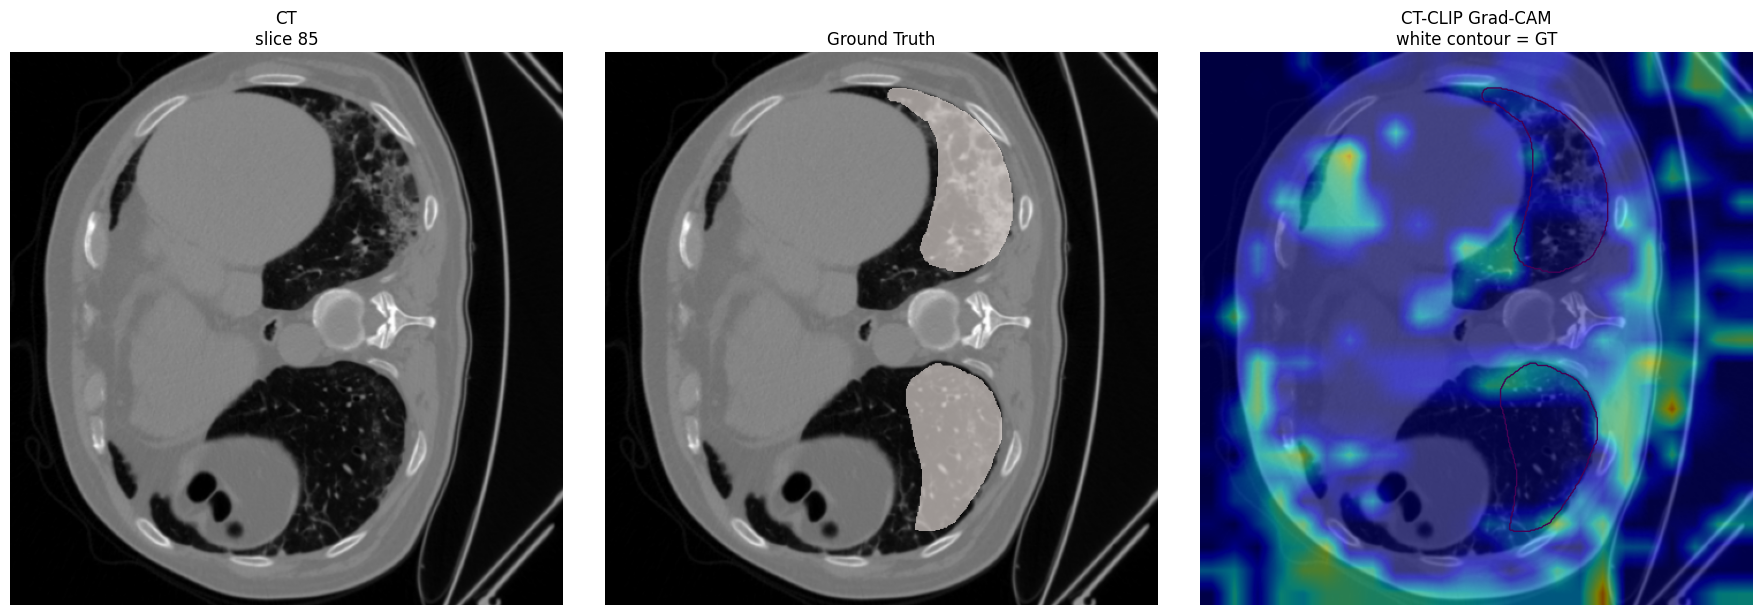

In [6]:

# ============================================================
# CT-CLIP Grad-CAM Visualization Notebook
# Corrected version
# ============================================================


import sys
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

import torch



# ============================================================
# Imports
# ============================================================

sys.path.insert(
    0,
    "/home/chest_ct/code/models/ct-clip/scripts"
)


from rexground_pilot_pipeline import (
    preprocess_ct,
    TRAIN_META,
    VALID_META,
    SEG_DIR,
    ROOT,
    TARGET_SHAPE,
    TARGET_SPACING,
    VOLUME_DIR
)

from data import resize_array



# ============================================================
# Select best CT-CLIP Grad-CAM case
# ============================================================

name = "train_655_a_2.nii.gz"


summary_path = (
    ROOT /
    "rexground_predictions/full/gradcam_summary_top20.csv"
)


summary = pd.read_csv(summary_path)


row = summary[
    summary["name"] == name
].iloc[0]


print(row)



# ============================================================
# Load metadata
# ============================================================

train_meta = pd.read_csv(
    TRAIN_META
).set_index("VolumeName")


valid_meta = pd.read_csv(
    VALID_META
).set_index("VolumeName")


if name in train_meta.index:
    meta_row = train_meta.loc[name]
else:
    meta_row = valid_meta.loc[name]


print("\nMetadata loaded")



# ============================================================
# Load CT using CT-CLIP preprocessing
# ============================================================

image_tensor, crop_info = preprocess_ct(
    VOLUME_DIR / name,
    meta_row
)


# CT format from pipeline:
# Z,X,Y

img_zxy = image_tensor.squeeze().numpy()


# Convert to:
# X,Y,Z

ct = np.transpose(
    img_zxy,
    (1,2,0)
)


print("\nCT shape:")
print(ct.shape)



# ============================================================
# Ground truth loader
# ============================================================

def load_gt(name, crop_info, meta_row):


    seg_path = SEG_DIR / name


    print(
        "\nLoading GT:",
        seg_path
    )


    seg = nib.load(
        str(seg_path)
    ).get_fdata()



    if seg.ndim == 4:
        seg = seg[0]


    seg_mask = seg > 0



    print(
        "Original GT:",
        seg_mask.shape
    )



    # --------------------------------------------------------
    # XYZ -> ZXY
    # --------------------------------------------------------

    seg_zxy = np.transpose(
        seg_mask.astype(np.float32),
        (2,0,1)
    )


    seg_tensor = torch.tensor(
        seg_zxy
    )[None,None]



    xy_spacing = float(
        meta_row["XYSpacing"][1:][:-2].split(",")[0]
    )


    z_spacing = float(
        meta_row["ZSpacing"]
    )



    # --------------------------------------------------------
    # Same resampling as CT-CLIP
    # --------------------------------------------------------

    seg_resize = resize_array(
        seg_tensor,
        (
            z_spacing,
            xy_spacing,
            xy_spacing
        ),
        TARGET_SPACING
    )


    print(
        "After resize type:",
        type(seg_resize)
    )


    print(
        "After resize shape:",
        seg_resize.shape
    )



    # remove batch/channel

    seg_resize = seg_resize[0,0]



    # --------------------------------------------------------
    # ZXY -> XYZ
    # --------------------------------------------------------

    seg_resize = np.transpose(
        seg_resize,
        (1,2,0)
    )



    print(
        "Resized GT XYZ:",
        seg_resize.shape
    )



    # --------------------------------------------------------
    # Crop
    # --------------------------------------------------------

    dh, dw, dd = TARGET_SHAPE


    hs = crop_info["h_start"]
    ws = crop_info["w_start"]
    ds = crop_info["d_start"]



    seg_crop = seg_resize[
        hs:hs+dh,
        ws:ws+dw,
        ds:ds+dd
    ]



    print(
        "Cropped GT:",
        seg_crop.shape
    )



    # --------------------------------------------------------
    # Padding
    # --------------------------------------------------------

    seg_pad = np.pad(
        seg_crop,
        (
            (
                crop_info["pad_h_before"],
                dh -
                seg_crop.shape[0]
                -
                crop_info["pad_h_before"]
            ),

            (
                crop_info["pad_w_before"],
                dw -
                seg_crop.shape[1]
                -
                crop_info["pad_w_before"]
            ),

            (
                crop_info["pad_d_before"],
                dd -
                seg_crop.shape[2]
                -
                crop_info["pad_d_before"]
            )
        ),
        mode="constant",
        constant_values=0
    )



    return seg_pad > 0.5




gt = load_gt(
    name,
    crop_info,
    meta_row
)


print(
    "\nFinal GT:",
    gt.shape
)


print(
    "GT voxels:",
    gt.sum()
)



# ============================================================
# Load Grad-CAM
# ============================================================

cam_path = row["gradcam_npy"]


print(
    "\nLoading CAM:",
    cam_path
)



cam_zxy = np.load(
    cam_path
)



# CAM stored as:
# Z,X,Y

cam = np.transpose(
    cam_zxy,
    (1,2,0)
)



print(
    "CAM shape:",
    cam.shape
)



print(
    "CAM range:",
    cam.min(),
    cam.max()
)



# ============================================================
# Normalize CAM
# ============================================================

cam = cam - cam.min()

cam = cam / (
    cam.max() + 1e-8
)



# ============================================================
# Alignment check
# ============================================================

print("\nShape check")

print(
    "CT :",
    ct.shape
)

print(
    "GT :",
    gt.shape
)

print(
    "CAM:",
    cam.shape
)



assert ct.shape == gt.shape == cam.shape, \
    "CT, GT and CAM dimensions do not match"



# ============================================================
# Find best slice
# ============================================================

best_score = -1

slice_idx = 0


for z in range(gt.shape[2]):

    if gt[:,:,z].sum() == 0:
        continue


    score = (
        cam[:,:,z] *
        gt[:,:,z]
    ).sum()



    if score > best_score:

        best_score = score
        slice_idx = z



print(
    "\nSelected slice:",
    slice_idx
)


print(
    "Overlap score:",
    best_score
)



# ============================================================
# Visualization
# ============================================================


plt.figure(
    figsize=(18,6)
)



# CT

plt.subplot(
    1,3,1
)


plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.title(
    f"CT\nslice {slice_idx}"
)


plt.axis("off")




# GT

plt.subplot(
    1,3,2
)


plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    np.ma.masked_where(
        gt[:,:,slice_idx]==0,
        gt[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.6
)


plt.title(
    "Ground Truth"
)


plt.axis("off")




# GradCAM

plt.subplot(
    1,3,3
)


plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    cam[:,:,slice_idx],
    cmap="jet",
    alpha=0.5,
    vmin=0,
    vmax=1
)



plt.contour(
    gt[:,:,slice_idx],
    levels=[0.5],
    linewidths=1
)



plt.title(
    "CT-CLIP Grad-CAM\nwhite contour = GT"
)


plt.axis("off")



plt.tight_layout()

plt.show()

name                                                 train_655_a_2.nii.gz
split                                                                test
kind                                                                  ggo
categories                                                             2c
pixels                                                            1317095
findings                Bilateral multilobar, predominantly peripheral...
prob_lung_nodule                                                 0.495762
prob_lung_opacity                                                0.562429
logit_lung_nodule                                               -0.016953
logit_lung_opacity                                               0.251028
gradcam_target                                                        ggo
target_prob                                                      0.562429
gradcam_npy             /home/chest_ct/code/models/ct-clip/rexground_p...
gradcam_best_dice                     

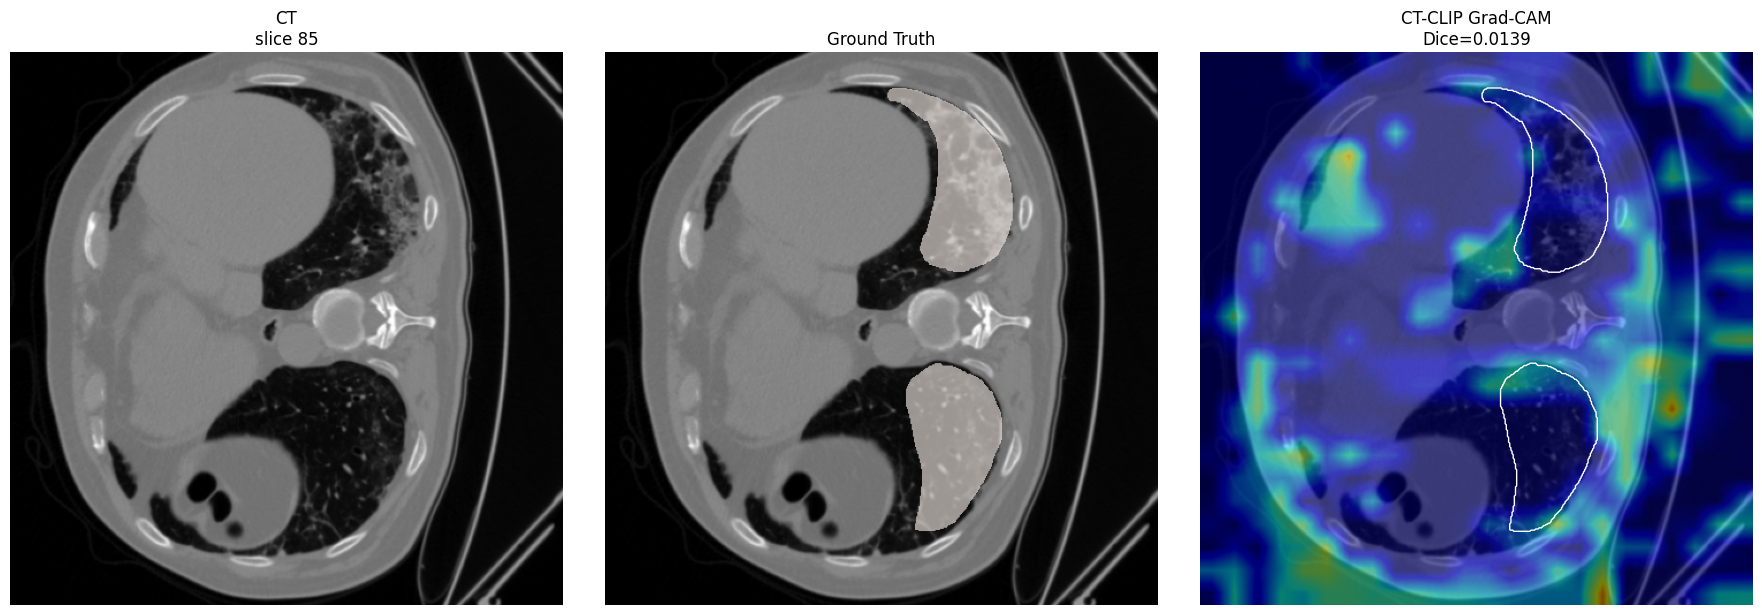

In [7]:
# ============================================================
# CT-CLIP Grad-CAM Visualization + Dice Evaluation
# ============================================================


import sys
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import torch



# ============================================================
# Imports
# ============================================================

sys.path.insert(
    0,
    "/home/chest_ct/code/models/ct-clip/scripts"
)


from rexground_pilot_pipeline import (
    preprocess_ct,
    TRAIN_META,
    VALID_META,
    SEG_DIR,
    ROOT,
    TARGET_SHAPE,
    TARGET_SPACING,
    VOLUME_DIR
)

from data import resize_array



# ============================================================
# Select case
# ============================================================

# Best GGO case from your CSV

name = "train_655_a_2.nii.gz"


summary_path = (
    ROOT /
    "rexground_predictions/full/gradcam_summary_top20.csv"
)


summary = pd.read_csv(summary_path)


row = summary[
    summary["name"] == name
].iloc[0]


print(row)



# ============================================================
# Load metadata
# ============================================================

train_meta = pd.read_csv(
    TRAIN_META
).set_index("VolumeName")


valid_meta = pd.read_csv(
    VALID_META
).set_index("VolumeName")



if name in train_meta.index:
    meta_row = train_meta.loc[name]
else:
    meta_row = valid_meta.loc[name]



print("\nMetadata loaded")



# ============================================================
# Load CT
# ============================================================

image_tensor, crop_info = preprocess_ct(
    VOLUME_DIR / name,
    meta_row
)


# CT output:
# Z,X,Y

ct_zxy = image_tensor.squeeze().numpy()


# convert:
# X,Y,Z

ct = np.transpose(
    ct_zxy,
    (1,2,0)
)


print(
    "\nCT shape:",
    ct.shape
)



# ============================================================
# Load aligned GT
# ============================================================


def load_gt(name, crop_info, meta_row):


    seg_path = SEG_DIR / name


    print(
        "\nLoading GT:",
        seg_path
    )


    seg = nib.load(
        str(seg_path)
    ).get_fdata()



    if seg.ndim == 4:
        seg = seg[0]



    seg_mask = seg > 0



    print(
        "Original GT:",
        seg_mask.shape
    )



    # XYZ -> ZXY

    seg_zxy = np.transpose(
        seg_mask.astype(np.float32),
        (2,0,1)
    )



    seg_tensor = torch.tensor(
        seg_zxy
    )[None,None]



    xy_spacing = float(
        meta_row["XYSpacing"][1:][:-2].split(",")[0]
    )


    z_spacing = float(
        meta_row["ZSpacing"]
    )



    # same preprocessing as CT

    seg_resize = resize_array(
        seg_tensor,
        (
            z_spacing,
            xy_spacing,
            xy_spacing
        ),
        TARGET_SPACING
    )



    # remove batch/channel

    seg_resize = seg_resize[0,0]



    print(
        "After resize:",
        seg_resize.shape
    )



    # ZXY -> XYZ

    seg_resize = np.transpose(
        seg_resize,
        (1,2,0)
    )



    dh,dw,dd = TARGET_SHAPE



    hs = crop_info["h_start"]
    ws = crop_info["w_start"]
    ds = crop_info["d_start"]



    seg_crop = seg_resize[
        hs:hs+dh,
        ws:ws+dw,
        ds:ds+dd
    ]



    seg_pad = np.pad(
        seg_crop,
        (
            (
                crop_info["pad_h_before"],
                dh -
                seg_crop.shape[0]
                -
                crop_info["pad_h_before"]
            ),

            (
                crop_info["pad_w_before"],
                dw -
                seg_crop.shape[1]
                -
                crop_info["pad_w_before"]
            ),

            (
                crop_info["pad_d_before"],
                dd -
                seg_crop.shape[2]
                -
                crop_info["pad_d_before"]
            )
        ),
        mode="constant",
        constant_values=0
    )



    return seg_pad > 0.5





gt = load_gt(
    name,
    crop_info,
    meta_row
)



print(
    "\nGT shape:",
    gt.shape
)


print(
    "GT voxels:",
    gt.sum()
)



# ============================================================
# Load Grad-CAM
# ============================================================


cam_path = row["gradcam_npy"]


print(
    "\nLoading CAM:",
    cam_path
)



cam_zxy = np.load(
    cam_path
)



# ZXY -> XYZ

cam = np.transpose(
    cam_zxy,
    (1,2,0)
)



print(
    "CAM shape:",
    cam.shape
)



# ============================================================
# Normalize CAM
# ============================================================

cam = cam - cam.min()

cam = cam / (
    cam.max() + 1e-8
)



# ============================================================
# Verify alignment
# ============================================================


print("\nAlignment check")

print(
    "CT :",
    ct.shape
)

print(
    "GT :",
    gt.shape
)

print(
    "CAM:",
    cam.shape
)



assert (
    ct.shape ==
    gt.shape ==
    cam.shape
), "CT, GT and CAM shapes mismatch"



# ============================================================
# Dice evaluation
# ============================================================


best_pct = int(
    row["gradcam_best_pct"]
)


threshold = np.percentile(
    cam,
    best_pct
)



cam_mask = cam >= threshold



intersection = np.logical_and(
    cam_mask,
    gt
).sum()



dice = (
    2*intersection /
    (
        cam_mask.sum()
        +
        gt.sum()
        +
        1e-8
    )
)



iou = intersection / (
    np.logical_or(cam_mask,gt).sum()
    +
    1e-8
)



print("\n========================")
print("Grad-CAM Evaluation")
print("========================")


print(
    "Threshold percentile:",
    best_pct
)

print(
    "Threshold:",
    threshold
)


print(
    "CAM voxels:",
    cam_mask.sum()
)


print(
    "GT voxels:",
    gt.sum()
)


print(
    "Intersection:",
    intersection
)


print(
    "Dice:",
    dice
)


print(
    "IoU:",
    iou
)



# ============================================================
# Select best visualization slice
# ============================================================


best_score = -1
slice_idx = 0



for z in range(gt.shape[2]):

    if gt[:,:,z].sum()==0:
        continue


    score = (
        cam[:,:,z] *
        gt[:,:,z]
    ).sum()



    if score > best_score:

        best_score = score
        slice_idx = z



print(
    "\nSelected slice:",
    slice_idx
)


print(
    "Overlap score:",
    best_score
)



# ============================================================
# Visualization
# ============================================================


plt.figure(
    figsize=(18,6)
)



# CT

plt.subplot(
    1,3,1
)


plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.title(
    f"CT\nslice {slice_idx}"
)


plt.axis("off")




# GT

plt.subplot(
    1,3,2
)


plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)



plt.imshow(
    np.ma.masked_where(
        gt[:,:,slice_idx]==0,
        gt[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.6
)



plt.title(
    "Ground Truth"
)


plt.axis("off")




# GradCAM

plt.subplot(
    1,3,3
)



plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)



plt.imshow(
    cam[:,:,slice_idx],
    cmap="jet",
    alpha=0.5,
    vmin=0,
    vmax=1
)



plt.contour(
    gt[:,:,slice_idx],
    levels=[0.5],
    colors="white",
    linewidths=1
)



plt.title(
    f"CT-CLIP Grad-CAM\nDice={dice:.4f}"
)


plt.axis("off")



plt.tight_layout()

plt.show()

name                                                 train_655_a_2.nii.gz
split                                                                test
kind                                                                  ggo
categories                                                             2c
pixels                                                            1317095
findings                Bilateral multilobar, predominantly peripheral...
prob_lung_nodule                                                 0.495762
prob_lung_opacity                                                0.562429
logit_lung_nodule                                               -0.016953
logit_lung_opacity                                               0.251028
gradcam_target                                                        ggo
target_prob                                                      0.562429
gradcam_npy             /home/chest_ct/code/models/ct-clip/rexground_p...
gradcam_best_dice                     

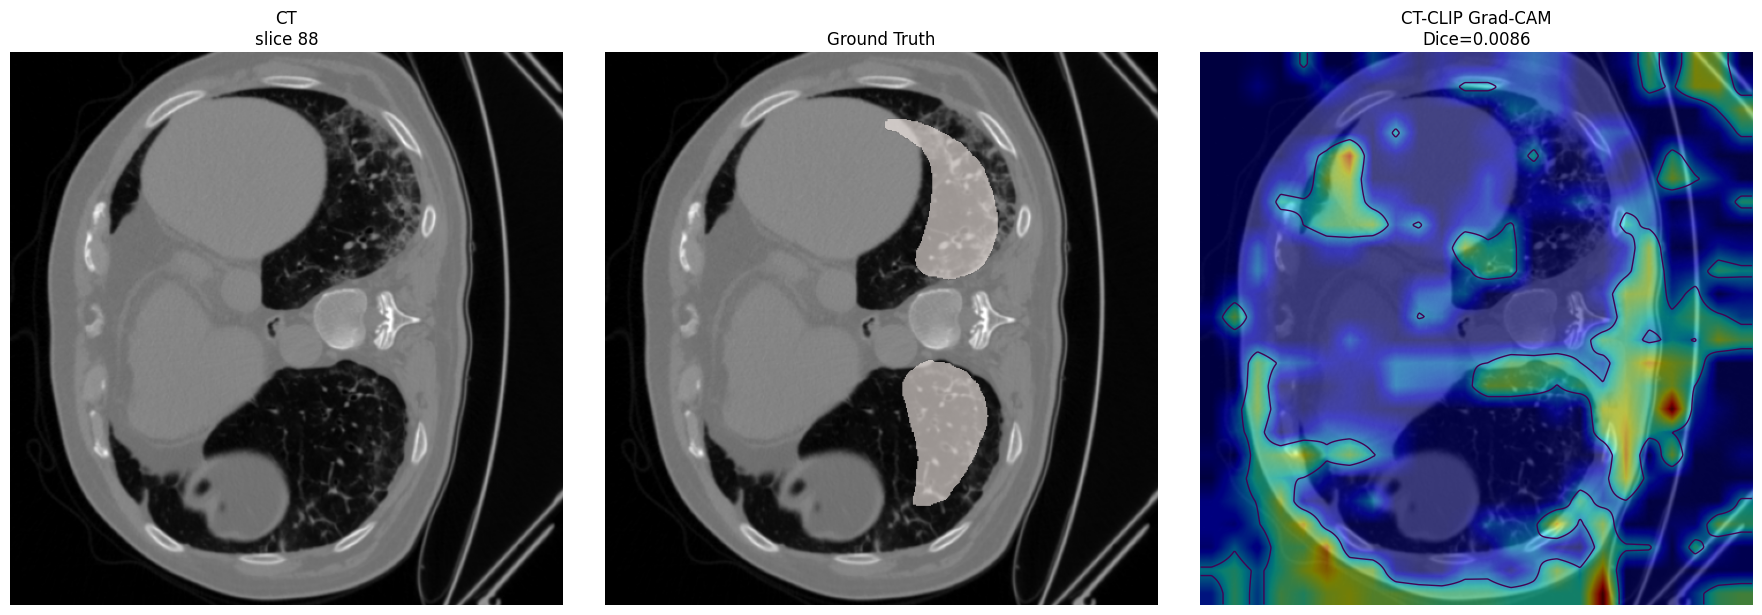

In [8]:
# ============================================================
# CT-CLIP Grad-CAM + GT Visualization (FINAL CORRECTED)
# ============================================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F


# ============================================================
# Imports
# ============================================================

sys.path.insert(
    0,
    "/home/chest_ct/code/models/ct-clip/scripts"
)


from rexground_pilot_pipeline import (
    preprocess_ct,
    TRAIN_META,
    VALID_META,
    SEG_DIR,
    ROOT,
    VOLUME_DIR
)



# ============================================================
# Select best case
# ============================================================

name = "train_655_a_2.nii.gz"


summary_path = (
    ROOT /
    "rexground_predictions/full/gradcam_summary_top20.csv"
)


summary = pd.read_csv(summary_path)


row = summary[
    summary["name"] == name
].iloc[0]


print(row)



# ============================================================
# Metadata
# ============================================================

train_meta = pd.read_csv(
    TRAIN_META
).set_index("VolumeName")


valid_meta = pd.read_csv(
    VALID_META
).set_index("VolumeName")


if name in train_meta.index:
    meta_row = train_meta.loc[name]
else:
    meta_row = valid_meta.loc[name]


print("Metadata loaded")



# ============================================================
# Load CT with CT-CLIP preprocessing
# ============================================================

image_tensor, crop_info = preprocess_ct(
    VOLUME_DIR / name,
    meta_row
)


# Z,X,Y

ct = image_tensor.squeeze().numpy()


# X,Y,Z

ct = np.transpose(
    ct,
    (1,2,0)
)


print("\nCT shape:")
print(ct.shape)



# ============================================================
# Load GT
# ============================================================

gt_path = SEG_DIR / name


print("\nLoading GT:", gt_path)


gt_nii = nib.load(
    str(gt_path)
)


gt = gt_nii.get_fdata()


if gt.ndim == 4:
    gt = gt[0]


gt = gt > 0



print(
    "Original GT:",
    gt.shape
)



# ============================================================
# Resize GT directly to CT-CLIP resolution
# ============================================================

gt_tensor = torch.tensor(
    gt.astype(np.float32)
)


# XYZ -> ZYX for interpolation

gt_tensor = gt_tensor.permute(
    2,0,1
)


gt_tensor = gt_tensor.unsqueeze(0).unsqueeze(0)



gt_resize = F.interpolate(
    gt_tensor,
    size=(
        ct.shape[2],
        ct.shape[0],
        ct.shape[1]
    ),
    mode="nearest"
)



gt_resize = gt_resize.squeeze().numpy()



# ZXY -> XYZ

gt_resize = np.transpose(
    gt_resize,
    (1,2,0)
)



gt = gt_resize > 0.5



print(
    "Aligned GT:",
    gt.shape
)


print(
    "GT voxels:",
    gt.sum()
)



# ============================================================
# Load CAM
# ============================================================

cam_path = row["gradcam_npy"]


print(
    "\nLoading CAM:",
    cam_path
)


cam = np.load(
    cam_path
)



# ZXY -> XYZ

cam = np.transpose(
    cam,
    (1,2,0)
)



# normalize

cam = cam - cam.min()

cam = cam / (
    cam.max()+1e-8
)



print(
    "\nCAM:",
    cam.shape
)



# ============================================================
# Verify alignment
# ============================================================

print("\nFINAL SHAPES")

print("CT :",ct.shape)

print("GT :",gt.shape)

print("CAM:",cam.shape)



assert ct.shape == gt.shape == cam.shape



# ============================================================
# Dice calculation
# ============================================================


threshold = np.percentile(
    cam,
    row["gradcam_best_pct"]
)


cam_mask = cam >= threshold



intersection = np.logical_and(
    cam_mask,
    gt
).sum()


dice = (
    2*intersection /
    (
        cam_mask.sum()
        +
        gt.sum()
        +
        1e-8
    )
)


iou = (
    intersection /
    (
        np.logical_or(cam_mask,gt).sum()
        +
        1e-8
    )
)


print("\nEvaluation")

print(
    "Dice:",
    dice
)


print(
    "IoU:",
    iou
)



# ============================================================
# Select best lesion slice
# ============================================================


slice_idx = np.argmax(
    gt.sum(axis=(0,1))
)


print(
    "\nSlice:",
    slice_idx
)



# ============================================================
# Visualization
# ============================================================

plt.figure(
    figsize=(18,6)
)



# CT

plt.subplot(1,3,1)

plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)

plt.title(
    f"CT\nslice {slice_idx}"
)

plt.axis("off")



# GT

plt.subplot(1,3,2)


plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    np.ma.masked_where(
        gt[:,:,slice_idx]==0,
        gt[:,:,slice_idx]
    ),
    cmap="Reds",
    alpha=0.6
)


plt.title(
    "Ground Truth"
)


plt.axis("off")



# CAM

plt.subplot(1,3,3)


plt.imshow(
    ct[:,:,slice_idx],
    cmap="gray"
)


plt.imshow(
    cam[:,:,slice_idx],
    cmap="jet",
    alpha=0.5
)


plt.contour(
    cam[:,:,slice_idx],
    levels=[threshold],
    linewidths=1
)


plt.title(
    f"CT-CLIP Grad-CAM\nDice={dice:.4f}"
)


plt.axis("off")



plt.tight_layout()

plt.show()

name                                                 train_655_a_2.nii.gz
split                                                                test
kind                                                                  ggo
categories                                                             2c
pixels                                                            1317095
findings                Bilateral multilobar, predominantly peripheral...
prob_lung_nodule                                                 0.495762
prob_lung_opacity                                                0.562429
logit_lung_nodule                                               -0.016953
logit_lung_opacity                                               0.251028
gradcam_target                                                        ggo
target_prob                                                      0.562429
gradcam_npy             /home/chest_ct/code/models/ct-clip/rexground_p...
gradcam_best_dice                     

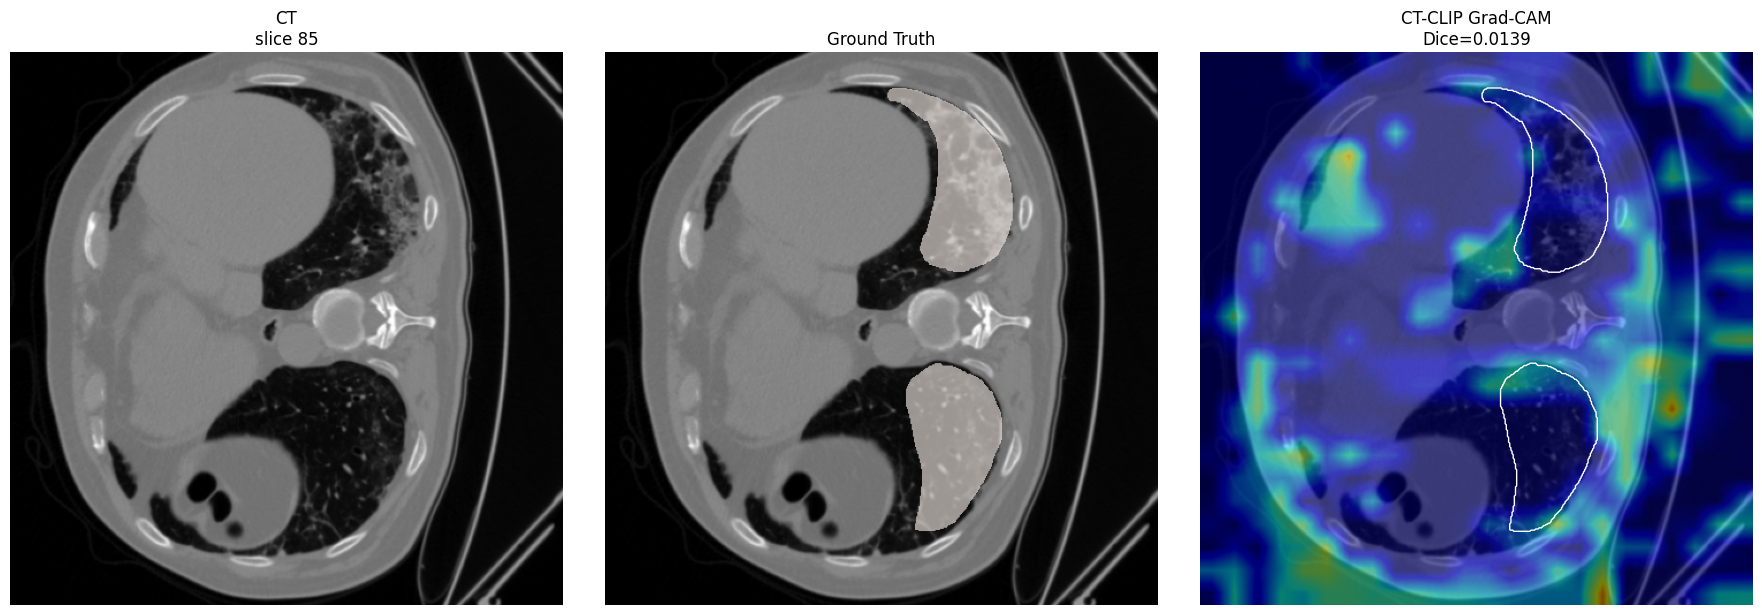

In [9]:
# ============================================================
# CT-CLIP Grad-CAM + GT Visualization (ALIGNMENT-CORRECT)
# ============================================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import torch


# ============================================================
# Imports
# ============================================================

sys.path.insert(
    0,
    "/home/chest_ct/code/models/ct-clip/scripts"
)

from rexground_pilot_pipeline import (
    preprocess_ct,
    TRAIN_META,
    VALID_META,
    SEG_DIR,
    ROOT,
    TARGET_SHAPE,
    TARGET_SPACING,
    VOLUME_DIR
)

from data import resize_array


# ============================================================
# Select case
# ============================================================

name = "train_655_a_2.nii.gz"

summary_path = (
    ROOT /
    "rexground_predictions/full/gradcam_summary_top20.csv"
)

summary = pd.read_csv(summary_path)

row = summary[summary["name"] == name].iloc[0]

print(row)


# ============================================================
# Metadata
# ============================================================

train_meta = pd.read_csv(TRAIN_META).set_index("VolumeName")
valid_meta = pd.read_csv(VALID_META).set_index("VolumeName")

if name in train_meta.index:
    meta_row = train_meta.loc[name]
else:
    meta_row = valid_meta.loc[name]

print("\nMetadata loaded")


# ============================================================
# Load CT with CT-CLIP preprocessing
# ============================================================

image_tensor, crop_info = preprocess_ct(
    VOLUME_DIR / name,
    meta_row
)

print("\ncrop_info:")
print(crop_info)

# Z,X,Y
ct_zxy = image_tensor.squeeze().numpy()

# X,Y,Z
ct = np.transpose(ct_zxy, (1, 2, 0))

print("\nCT shape:", ct.shape)


# ============================================================
# Load GT and replay the SAME resample -> crop -> pad pipeline
# ============================================================

def load_gt_aligned(name, crop_info, meta_row):

    seg_path = SEG_DIR / name
    print("\nLoading GT:", seg_path)

    seg = nib.load(str(seg_path)).get_fdata()

    if seg.ndim == 4:
        seg = seg[0]

    seg_mask = seg > 0

    print("Original GT:", seg_mask.shape)

    # XYZ -> ZXY (match CT's raw axis order before resampling)
    seg_zxy = np.transpose(seg_mask.astype(np.float32), (2, 0, 1))

    seg_tensor = torch.tensor(seg_zxy)[None, None]

    xy_spacing = float(
        meta_row["XYSpacing"][1:][:-2].split(",")[0]
    )
    z_spacing = float(meta_row["ZSpacing"])

    # Resample to the SAME target spacing used for CT
    seg_resize = resize_array(
        seg_tensor,
        (z_spacing, xy_spacing, xy_spacing),
        TARGET_SPACING
    )

    seg_resize = seg_resize[0, 0]

    print("After resample:", seg_resize.shape)

    # ZXY -> XYZ
    seg_resize = np.transpose(seg_resize, (1, 2, 0))

    dh, dw, dd = TARGET_SHAPE

    hs = crop_info["h_start"]
    ws = crop_info["w_start"]
    ds = crop_info["d_start"]

    # Guard: if the resampled GT is smaller than the crop window
    # on any axis, this will slice short rather than error, so
    # print shapes to sanity check before trusting the crop.
    seg_crop = seg_resize[
        hs:hs + dh,
        ws:ws + dw,
        ds:ds + dd
    ]

    pad_h_after = dh - seg_crop.shape[0] - crop_info["pad_h_before"]
    pad_w_after = dw - seg_crop.shape[1] - crop_info["pad_w_before"]
    pad_d_after = dd - seg_crop.shape[2] - crop_info["pad_d_before"]

    seg_pad = np.pad(
        seg_crop,
        (
            (crop_info["pad_h_before"], pad_h_after),
            (crop_info["pad_w_before"], pad_w_after),
            (crop_info["pad_d_before"], pad_d_after),
        ),
        mode="constant",
        constant_values=0
    )

    return seg_pad > 0.5


gt = load_gt_aligned(name, crop_info, meta_row)

print("\nAligned GT shape:", gt.shape)
print("GT voxels:", gt.sum())


# ============================================================
# Load CAM
# ============================================================

cam_path = row["gradcam_npy"]
print("\nLoading CAM:", cam_path)

cam_zxy = np.load(cam_path)

# ZXY -> XYZ
cam = np.transpose(cam_zxy, (1, 2, 0))

# normalize
cam = cam - cam.min()
cam = cam / (cam.max() + 1e-8)

print("CAM shape:", cam.shape)


# ============================================================
# Verify alignment
# ============================================================

print("\nFINAL SHAPES")
print("CT :", ct.shape)
print("GT :", gt.shape)
print("CAM:", cam.shape)

assert ct.shape == gt.shape == cam.shape, (
    f"Shape mismatch — CT {ct.shape}, GT {gt.shape}, CAM {cam.shape}. "
    "Check TARGET_SHAPE/crop_info consistency between preprocess_ct and load_gt_aligned."
)


# ============================================================
# Dice / IoU
# ============================================================

threshold = np.percentile(cam, row["gradcam_best_pct"])
cam_mask = cam >= threshold

intersection = np.logical_and(cam_mask, gt).sum()

dice = 2 * intersection / (cam_mask.sum() + gt.sum() + 1e-8)
iou = intersection / (np.logical_or(cam_mask, gt).sum() + 1e-8)

print("\nEvaluation")
print("Threshold:", threshold)
print("CAM voxels:", cam_mask.sum())
print("GT voxels:", gt.sum())
print("Intersection:", intersection)
print("Dice:", dice)
print("IoU:", iou)


# ============================================================
# Select best overlap slice (not just biggest GT slice)
# ============================================================

best_score = -1
slice_idx = 0

for z in range(gt.shape[2]):
    if gt[:, :, z].sum() == 0:
        continue
    score = (cam[:, :, z] * gt[:, :, z]).sum()
    if score > best_score:
        best_score = score
        slice_idx = z

print("\nSelected slice:", slice_idx)
print("Overlap score:", best_score)


# ============================================================
# Visualization
# ============================================================

plt.figure(figsize=(18, 6))

# CT
plt.subplot(1, 3, 1)
plt.imshow(ct[:, :, slice_idx], cmap="gray")
plt.title(f"CT\nslice {slice_idx}")
plt.axis("off")

# GT
plt.subplot(1, 3, 2)
plt.imshow(ct[:, :, slice_idx], cmap="gray")
plt.imshow(
    np.ma.masked_where(gt[:, :, slice_idx] == 0, gt[:, :, slice_idx]),
    cmap="Reds",
    alpha=0.6
)
plt.title("Ground Truth")
plt.axis("off")

# CAM
plt.subplot(1, 3, 3)
plt.imshow(ct[:, :, slice_idx], cmap="gray")
plt.imshow(cam[:, :, slice_idx], cmap="jet", alpha=0.5, vmin=0, vmax=1)
plt.contour(gt[:, :, slice_idx], levels=[0.5], colors="white", linewidths=1)
plt.title(f"CT-CLIP Grad-CAM\nDice={dice:.4f}")
plt.axis("off")

plt.tight_layout()
plt.show()

name                                                  train_34_a_2.nii.gz
split                                                                test
kind                                                               nodule
categories                                                             2d
pixels                                                                611
findings                Subcentimeter indeterminate nodules in both lungs
prob_lung_nodule                                                 0.532897
prob_lung_opacity                                                0.503944
logit_lung_nodule                                                0.131778
logit_lung_opacity                                               0.015778
gradcam_target                                                     nodule
target_prob                                                      0.532897
gradcam_npy             /home/chest_ct/code/models/ct-clip/rexground_p...
gradcam_best_dice                     

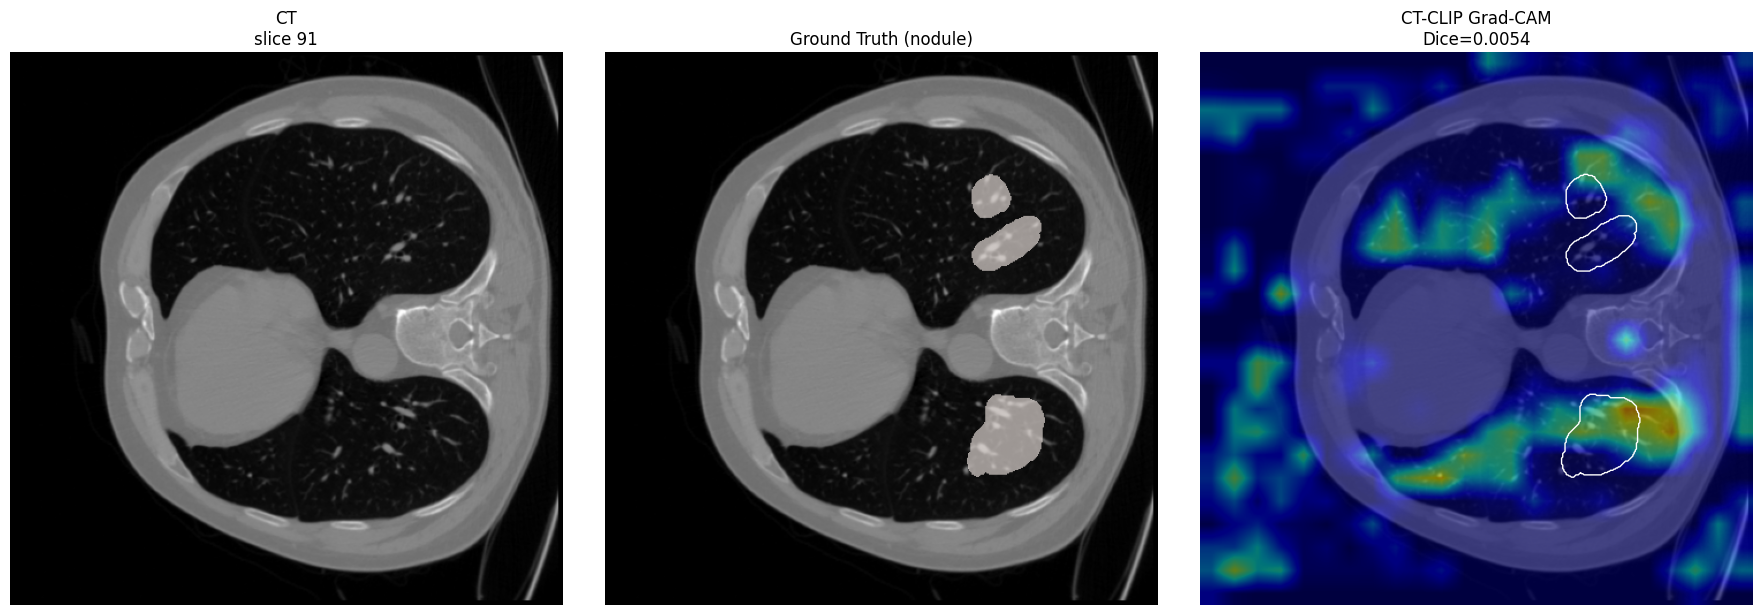

In [10]:
# ============================================================
# CT-CLIP Grad-CAM + GT Visualization (ALIGNMENT-CORRECT)
# Nodule case: train_34_a_2.nii.gz
# ============================================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import torch


# ============================================================
# Imports
# ============================================================

sys.path.insert(
    0,
    "/home/chest_ct/code/models/ct-clip/scripts"
)

from rexground_pilot_pipeline import (
    preprocess_ct,
    TRAIN_META,
    VALID_META,
    SEG_DIR,
    ROOT,
    TARGET_SHAPE,
    TARGET_SPACING,
    VOLUME_DIR
)

from data import resize_array


# ============================================================
# Select case
# ============================================================

name = "train_34_a_2.nii.gz"   # nodule case, best Dice = 0.0054

summary_path = (
    ROOT /
    "rexground_predictions/full/gradcam_summary_top20.csv"
)

summary = pd.read_csv(summary_path)

row = summary[summary["name"] == name].iloc[0]

print(row)


# ============================================================
# Metadata
# ============================================================

train_meta = pd.read_csv(TRAIN_META).set_index("VolumeName")
valid_meta = pd.read_csv(VALID_META).set_index("VolumeName")

if name in train_meta.index:
    meta_row = train_meta.loc[name]
else:
    meta_row = valid_meta.loc[name]

print("\nMetadata loaded")


# ============================================================
# Load CT with CT-CLIP preprocessing
# ============================================================

image_tensor, crop_info = preprocess_ct(
    VOLUME_DIR / name,
    meta_row
)

print("\ncrop_info:")
print(crop_info)

# Z,X,Y
ct_zxy = image_tensor.squeeze().numpy()

# X,Y,Z
ct = np.transpose(ct_zxy, (1, 2, 0))

print("\nCT shape:", ct.shape)


# ============================================================
# Load GT and replay the SAME resample -> crop -> pad pipeline
# ============================================================

def load_gt_aligned(name, crop_info, meta_row):

    seg_path = SEG_DIR / name
    print("\nLoading GT:", seg_path)

    seg = nib.load(str(seg_path)).get_fdata()

    if seg.ndim == 4:
        seg = seg[0]

    seg_mask = seg > 0

    print("Original GT:", seg_mask.shape)

    # XYZ -> ZXY (match CT's raw axis order before resampling)
    seg_zxy = np.transpose(seg_mask.astype(np.float32), (2, 0, 1))

    seg_tensor = torch.tensor(seg_zxy)[None, None]

    xy_spacing = float(
        meta_row["XYSpacing"][1:][:-2].split(",")[0]
    )
    z_spacing = float(meta_row["ZSpacing"])

    # Resample to the SAME target spacing used for CT
    seg_resize = resize_array(
        seg_tensor,
        (z_spacing, xy_spacing, xy_spacing),
        TARGET_SPACING
    )

    seg_resize = seg_resize[0, 0]

    print("After resample:", seg_resize.shape)

    # ZXY -> XYZ
    seg_resize = np.transpose(seg_resize, (1, 2, 0))

    dh, dw, dd = TARGET_SHAPE

    hs = crop_info["h_start"]
    ws = crop_info["w_start"]
    ds = crop_info["d_start"]

    seg_crop = seg_resize[
        hs:hs + dh,
        ws:ws + dw,
        ds:ds + dd
    ]

    pad_h_after = dh - seg_crop.shape[0] - crop_info["pad_h_before"]
    pad_w_after = dw - seg_crop.shape[1] - crop_info["pad_w_before"]
    pad_d_after = dd - seg_crop.shape[2] - crop_info["pad_d_before"]

    seg_pad = np.pad(
        seg_crop,
        (
            (crop_info["pad_h_before"], pad_h_after),
            (crop_info["pad_w_before"], pad_w_after),
            (crop_info["pad_d_before"], pad_d_after),
        ),
        mode="constant",
        constant_values=0
    )

    return seg_pad > 0.5


gt = load_gt_aligned(name, crop_info, meta_row)

print("\nAligned GT shape:", gt.shape)
print("GT voxels:", gt.sum())


# ============================================================
# Load CAM
# ============================================================

cam_path = row["gradcam_npy"]
print("\nLoading CAM:", cam_path)

cam_zxy = np.load(cam_path)

# ZXY -> XYZ
cam = np.transpose(cam_zxy, (1, 2, 0))

# normalize
cam = cam - cam.min()
cam = cam / (cam.max() + 1e-8)

print("CAM shape:", cam.shape)


# ============================================================
# Verify alignment
# ============================================================

print("\nFINAL SHAPES")
print("CT :", ct.shape)
print("GT :", gt.shape)
print("CAM:", cam.shape)

assert ct.shape == gt.shape == cam.shape, (
    f"Shape mismatch — CT {ct.shape}, GT {gt.shape}, CAM {cam.shape}. "
    "Check TARGET_SHAPE/crop_info consistency between preprocess_ct and load_gt_aligned."
)


# ============================================================
# Dice / IoU
# ============================================================

threshold = np.percentile(cam, row["gradcam_best_pct"])
cam_mask = cam >= threshold

intersection = np.logical_and(cam_mask, gt).sum()

dice = 2 * intersection / (cam_mask.sum() + gt.sum() + 1e-8)
iou = intersection / (np.logical_or(cam_mask, gt).sum() + 1e-8)

print("\nEvaluation")
print("Threshold:", threshold)
print("CAM voxels:", cam_mask.sum())
print("GT voxels:", gt.sum())
print("Intersection:", intersection)
print("Dice:", dice)
print("IoU:", iou)


# ============================================================
# Select best overlap slice (not just biggest GT slice)
# ============================================================

best_score = -1
slice_idx = 0

for z in range(gt.shape[2]):
    if gt[:, :, z].sum() == 0:
        continue
    score = (cam[:, :, z] * gt[:, :, z]).sum()
    if score > best_score:
        best_score = score
        slice_idx = z

print("\nSelected slice:", slice_idx)
print("Overlap score:", best_score)


# ============================================================
# Visualization
# ============================================================

plt.figure(figsize=(18, 6))

# CT
plt.subplot(1, 3, 1)
plt.imshow(ct[:, :, slice_idx], cmap="gray")
plt.title(f"CT\nslice {slice_idx}")
plt.axis("off")

# GT
plt.subplot(1, 3, 2)
plt.imshow(ct[:, :, slice_idx], cmap="gray")
plt.imshow(
    np.ma.masked_where(gt[:, :, slice_idx] == 0, gt[:, :, slice_idx]),
    cmap="Reds",
    alpha=0.6
)
plt.title("Ground Truth (nodule)")
plt.axis("off")

# CAM
plt.subplot(1, 3, 3)
plt.imshow(ct[:, :, slice_idx], cmap="gray")
plt.imshow(cam[:, :, slice_idx], cmap="jet", alpha=0.5, vmin=0, vmax=1)
plt.contour(gt[:, :, slice_idx], levels=[0.5], colors="white", linewidths=1)
plt.title(f"CT-CLIP Grad-CAM\nDice={dice:.4f}")
plt.axis("off")

plt.tight_layout()
plt.show()